# Credit Risk Prediction: Modeling & Evaluation

This notebook develops machine learning models for predicting borrower default risk using the engineered features created in Notebook 02.

The workflow includes:

- Loading engineered borrower data
- Preparing modeling features
- Training classification models
- Evaluating predictive performance
- Interpreting feature importance

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Load Engineered Dataset

Load the cleaned and feature-engineered borrower dataset prepared in Notebook 02.

In [2]:
# Load engineered dataset

credit = pd.read_csv(
    "/Users/Mandy/Desktop/GithubProjects/credit-risk-prediction/data/credit_risk_engineered.csv"
)

# Check dataset shape

credit.shape

(31521, 24)

# Dataset Inspection

Review the engineered dataset before model preparation.

In [4]:
# Preview dataset

credit.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,income_to_loan_ratio,credit_history_ratio,employment_stability,interest_burden
0,21,9600,5.0,B,1000,11.14,0,0.10,N,2,...,0,1,0,0,0,0,9.600000,0.095238,0.238095,0.001160
1,25,9600,1.0,C,5500,12.87,1,0.57,N,3,...,0,0,0,1,0,0,1.745455,0.120000,0.040000,0.001341
2,23,65500,4.0,C,35000,15.23,1,0.53,N,2,...,1,0,0,1,0,0,1.871429,0.086957,0.173913,0.000233
3,24,54400,8.0,C,35000,14.27,1,0.55,Y,4,...,1,0,0,1,0,0,1.554286,0.166667,0.333333,0.000262
4,21,9900,2.0,A,2500,7.14,1,0.25,N,2,...,0,0,0,0,0,1,3.960000,0.095238,0.095238,0.000721


In [5]:
# Display column names

credit.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_grade',
       'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_grade_encoded', 'default_history_encoded',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'income_to_loan_ratio',
       'credit_history_ratio', 'employment_stability', 'interest_burden'],
      dtype='object')

# Prediction Target

The objective is to predict borrower default risk using historical borrower characteristics and engineered financial indicators.

In [6]:
# Display target distribution

credit["loan_status"].value_counts()

0    24714
1     6807
Name: loan_status, dtype: int64

In [7]:
# Display target proportions

credit["loan_status"].value_counts(normalize=True)

0    0.784049
1    0.215951
Name: loan_status, dtype: float64

In [8]:
# Select modeling features

features = [

    # Original numerical features

    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",

    # Encoded features

    "loan_grade_encoded",
    "default_history_encoded",

    # Engineered features

    "income_to_loan_ratio",
    "credit_history_ratio",
    "employment_stability",
    "interest_burden"

]

In [9]:
# Create feature matrix

X = credit[features]

# Create target vector

y = credit["loan_status"]

X.shape

(31521, 13)

# Train-Test Split

Split the dataset into training and testing subsets.

The training dataset will be used to learn borrower risk patterns, while the testing dataset will evaluate model generalization performance on unseen borrowers.

In [10]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display dataset shapes

X_train.shape, X_test.shape

((25216, 13), (6305, 13))

# Logistic Regression Model

Train a baseline logistic regression classifier for borrower default prediction.

Logistic regression provides an interpretable benchmark model for binary classification tasks.

In [11]:
# Train logistic regression model

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [12]:
# Generate predictions

log_predictions = log_model.predict(
    X_test
)

print("Predictions generated.")

Predictions generated.


# Logistic Regression Evaluation

Evaluate predictive performance using classification accuracy and detailed classification metrics.

In [13]:
# Calculate model accuracy

log_accuracy = accuracy_score(
    y_test,
    log_predictions
)

print(
    "Logistic Regression Accuracy:",
    log_accuracy
)

Logistic Regression Accuracy: 0.8077716098334655


In [14]:
# Display classification report

print(
    classification_report(
        y_test,
        log_predictions
    )
)

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      4962
           1       0.70      0.17      0.28      1343

    accuracy                           0.81      6305
   macro avg       0.76      0.58      0.58      6305
weighted avg       0.79      0.81      0.76      6305



In [15]:
# Display confusion matrix

confusion_matrix(
    y_test,
    log_predictions
)

array([[4863,   99],
       [1113,  230]])

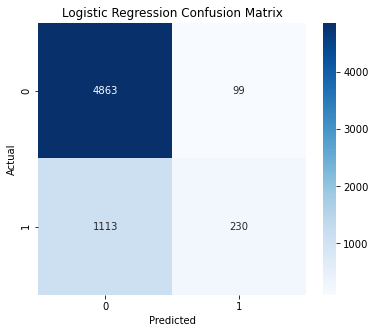

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    log_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Logistic Regression Findings

The logistic regression model achieved an overall accuracy of approximately 81%.

However, a detailed examination of classification metrics reveals that the model struggled to identify default borrowers.

While recall for non-default borrowers reached 98%, recall for default borrowers was only 17%.

This suggests that the model primarily learned to classify the majority non-default class and failed to capture a large proportion of risky borrowers.

For credit risk applications, improving default detection is often more important than maximizing overall accuracy.

# Random Forest Model

Train a tree-based ensemble model to capture non-linear borrower risk patterns.

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
# Train random forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training complete.")

Random Forest training complete.


In [19]:
# Generate predictions

rf_predictions = rf_model.predict(
    X_test
)

print("Predictions generated.")

Predictions generated.


In [20]:
# Calculate model accuracy

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    rf_accuracy
)

Random Forest Accuracy: 0.874385408406027


In [21]:
# Display classification report

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4962
           1       0.75      0.62      0.68      1343

    accuracy                           0.87      6305
   macro avg       0.82      0.78      0.80      6305
weighted avg       0.87      0.87      0.87      6305



In [22]:
# Display confusion matrix

rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

rf_cm

array([[4683,  279],
       [ 513,  830]])

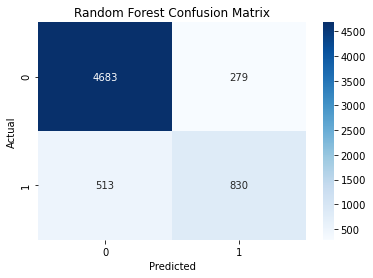

In [23]:
plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
# Extract feature importance

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
9,income_to_loan_ratio,0.173492
5,loan_percent_income,0.115961
7,loan_grade_encoded,0.111859
12,interest_burden,0.108381
4,loan_int_rate,0.104761
1,person_income,0.103714
3,loan_amnt,0.058621
11,employment_stability,0.058021
10,credit_history_ratio,0.048625
2,person_emp_length,0.040484


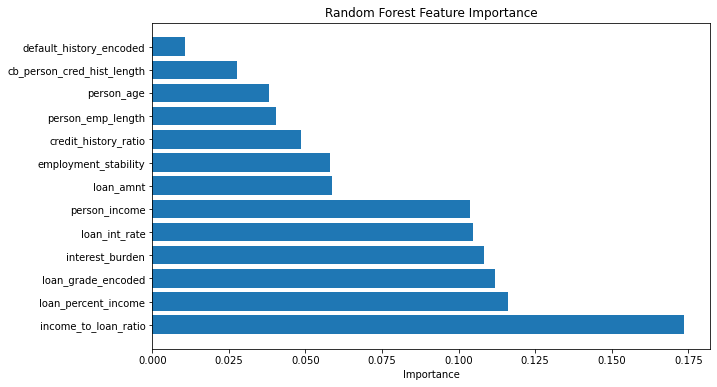

In [25]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")

plt.show()

# Random Forest Findings

The Random Forest model significantly outperformed Logistic Regression.

Model accuracy improved from 80.8% to 87.4%.

More importantly, recall for default borrowers increased from 17% to 62%, indicating a much stronger ability to identify high-risk borrowers.

Feature importance analysis revealed that debt affordability measures were the strongest predictors of default risk. The most important variables included:

- Income-to-loan ratio
- Loan percentage of income
- Loan grade
- Interest burden
- Loan interest rate

These findings suggest that borrower repayment capacity plays a critical role in predicting loan default behavior.